# 📊 Sentiment Analysis Final Project

---

## 🎯 Project Overview

Welcome to your Sentiment Analysis final project! In this project, you will:

- 🔍 **Analyze** customer reviews or social media text data
- 🧹 **Preprocess** text data using NLP techniques
- 🤖 **Build** and compare multiple classification models
- 📈 **Evaluate** model performance using appropriate metrics
- 💼 **Communicate** findings in a business context

---

## 📋 Project Requirements

- **Dataset**: Use a public sentiment dataset (e.g., IMDb reviews, Amazon reviews, airline tweets)
- **Models**: Train at least **2 different classification models**
- **Evaluation**: Use multiple metrics (accuracy, precision, recall, confusion matrix)
- **Documentation**: Use markdown cells to explain your approach, findings, and insights

---

## 💡 Important Tips for Success

### Working with Limited Resources
- ⚡ **Start small**: Use `df.sample(n=1000)` or `df.head(5000)` to work with a subset
- 🎯 **Limit vocabulary**: Use `max_features=5000` in TfidfVectorizer
- 🚀 **Choose efficient models**: LogisticRegression and MultinomialNB are fast and effective
- 💾 **Save your work frequently**: Use Ctrl+S or Cmd+S often

### Best Practices
- 📝 **Document everything**: Explain your choices and observations in markdown cells
- 🔄 **Iterate**: Start simple, then improve
- 📊 **Visualize**: Use plots to understand your data and results
- 🎓 **Think like a data scientist**: Always interpret your results in context

---

Let's get started! 🚀

---

# Part 1: Project Definition 🎯

## Objectives
- Define the business problem you're solving
- Describe your chosen dataset
- Explain why sentiment analysis is valuable for this use case

## Instructions

In the markdown cell below, answer these questions:

1. **What is the business problem?**
   - What decision or insight will this sentiment analysis support?
   - Who would use these results?

2. **What dataset are you using?**
   - Name and source of the dataset
   - Number of samples
   - What the text represents (reviews, tweets, comments, etc.)
   - What are the sentiment labels (positive/negative, star ratings, etc.)?

3. **Why is this problem important?**
   - How could the results be used in real-world scenarios?

---

## 📝 Your Project Definition

**Business Problem:**

Companies receive thousands of customer reviews every day, making it difficult to read each one manually. The goal of this project is to build a sentiment analysis model that can automatically classify reviews as positive or negative. These results can help businesses understand customer opinions, identify common issues, and improve products or services. Managers, marketing teams, and customer service teams can use these insights to make better business decisions.

---

**Dataset Description:**

This project uses the IMDb 50K Movie Reviews dataset, which contains movie reviews written by users. Each review is labeled as either positive or negative, making it suitable for binary sentiment classification.

- **Dataset name**: IMDb 50K Movie Reviews
- **Source**: Stanford AI Lab / IMDb Dataset
- **Number of samples**: 50,000 reviews
- **Text type**: Movie reviews
- **Sentiment labels**: Positive and Negative

---

**Importance and Real-World Applications:**

Sentiment analysis helps organizations quickly understand customer opinions without manually reading thousands of reviews. Businesses can use these results to monitor customer satisfaction, improve products, identify common complaints, and make better marketing and customer service decisions. Similar techniques are also used to analyze social media posts, product reviews, and customer feedback.

---

# Part 2: Exploratory Data Analysis (EDA) 🔍

## Objectives
- Load and examine your dataset
- Understand the distribution of sentiments
- Analyze text characteristics (length, common words, etc.)
- Identify any data quality issues

## What to Explore

✅ **Dataset structure**: Shape, columns, data types

✅ **Missing values**: Check for and handle missing data

✅ **Class distribution**: Are sentiments balanced?

✅ **Text length**: Average, min, max review lengths

✅ **Common words**: Most frequent words per sentiment

✅ **Sample reviews**: Display examples from each class

---

## 💡 Tips
- Use `.info()`, `.describe()`, and `.value_counts()` for quick insights
- Visualize distributions with bar plots and histograms
- Look for imbalanced classes that might affect model performance
- Create a word cloud to visualize common terms (optional but impressive!)

In [33]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [34]:
# Load your dataset
# Example: df = pd.read_csv('your_dataset.csv')
# For large datasets, consider using nrows parameter: pd.read_csv('file.csv', nrows=10000)

# YOUR CODE HERE
df = pd.read_csv("IMDB Dataset.csv", nrows=10000)

# Display basic information
print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {df.columns.tolist()}")
df.head()

Dataset shape: (10000, 2)

Column names: ['review', 'sentiment']


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [35]:
# Check for missing values
print(df.isnull().sum())

review       0
sentiment    0
dtype: int64


In [36]:
# Use a smaller sample to speed up processing
df_sample = df.sample(n=5000, random_state=42)

print(f"Working with {len(df_sample)} samples")

df = df_sample

Working with 5000 samples


sentiment
negative    2529
positive    2471
Name: count, dtype: int64


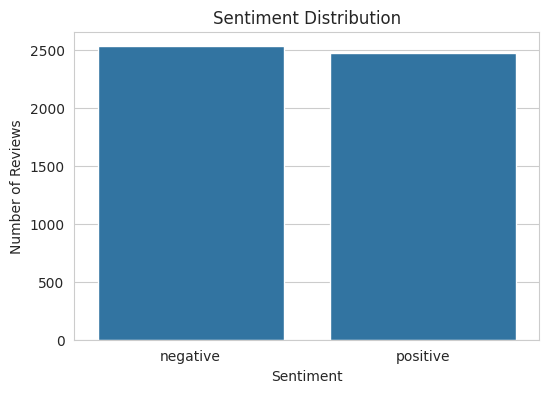

In [37]:
# Analyze sentiment distribution
sentiment_counts = df["sentiment"].value_counts()

print(sentiment_counts)

# Create a bar plot
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="sentiment")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()

### 📊 Interpretation: Class Balance

*Write your observations here:*
- Are the classes balanced or imbalanced?
- If imbalanced, how might this affect your model?
- What could you do to address imbalance?

count     5000.000000
mean      1325.833600
std        999.218078
min        101.000000
25%        701.000000
50%        966.000000
75%       1620.000000
max      10363.000000
Name: text_length, dtype: float64


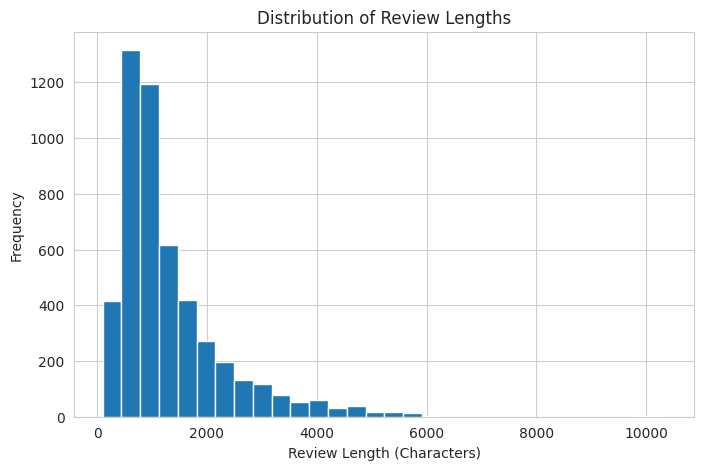

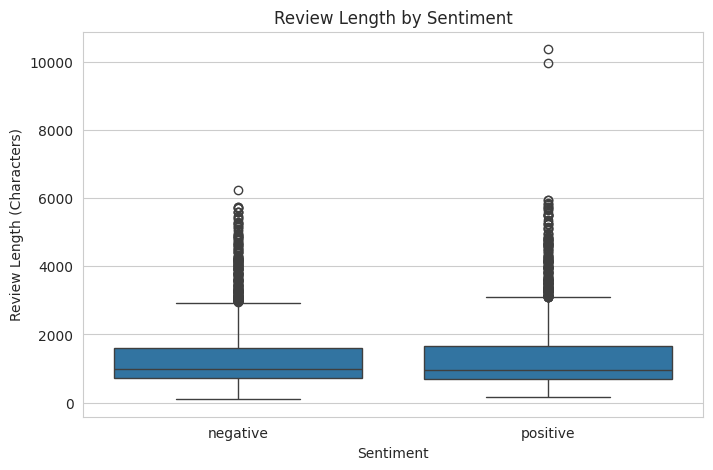

In [38]:
# Analyze text length distribution

# Create a new column for review length
df["text_length"] = df["review"].str.len()

# Summary statistics
print(df["text_length"].describe())

# Plot histogram
plt.figure(figsize=(8,5))
plt.hist(df["text_length"], bins=30)

plt.title("Distribution of Review Lengths")
plt.xlabel("Review Length (Characters)")
plt.ylabel("Frequency")
plt.show()

# Compare review lengths by sentiment
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="sentiment", y="text_length")

plt.title("Review Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Review Length (Characters)")
plt.show()

### 📊 Interpretation: Text Length

*Write your observations here:*
- What's the average text length?   
  1,326 characters.
- Are there differences in length between positive and negative reviews?  
  Very similar lengths, with positive reviews showing a slightly wider spread.
- Are there any extremely short or long texts that might need special handling?  
  Yes, there are some very long outliers (up to about 10,363 characters), but they don't necessarily need to be removed.

In [39]:
# Display sample reviews from each sentiment class

print("Positive Review Examples:\n")
print(df[df["sentiment"] == "positive"]["review"].sample(3, random_state=42))

print("\n" + "="*80 + "\n")

print("Negative Review Examples:\n")
print(df[df["sentiment"] == "negative"]["review"].sample(3, random_state=42))

Positive Review Examples:

3274    Well done melodrama that tells the story of Sa...
1423    If you want to watch a movie and feel good abo...
4428    Being a fan of Saint Etienne and the City of L...
Name: review, dtype: object


Negative Review Examples:

5225    I saw this movie a time ago, because some of m...
2836    I understand there was some conflict between L...
2458    It's a bit unnerving when a studio declines to...
Name: review, dtype: object


     Word  Frequency
0     the      64638
1       a      32382
2     and      32020
3      of      28822
4      to      26506
5      is      20930
6      in      18335
7       i      13933
8    this      13812
9    that      13065
10     it      13036
11  /><br      10463
12    was       9250
13     as       8832
14   with       8764
15    for       8651
16    but       7901
17     on       6414
18  movie       6247
19    his       5851


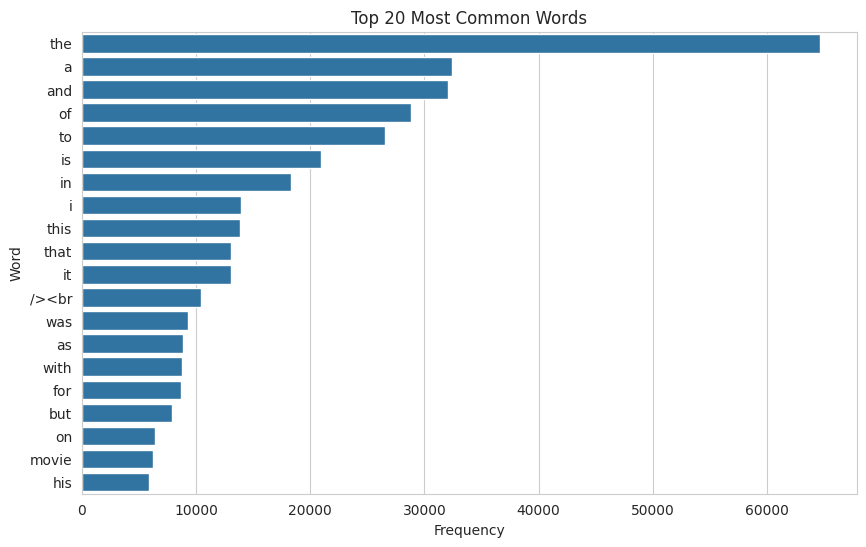

In [40]:
# Analyze common words
all_words = ' '.join(df['review']).lower().split()

common_words = Counter(all_words).most_common(20)

# Convert to DataFrame
common_words_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])

print(common_words_df)

# Plot the most common words
plt.figure(figsize=(10,6))
sns.barplot(data=common_words_df, x='Frequency', y='Word')

plt.title("Top 20 Most Common Words")
plt.xlabel("Frequency")
plt.ylabel("Word")

plt.show()

### 📝 EDA Summary

*Summarize your key findings from the EDA:*

1. **Dataset characteristics**: The dataset contains 50,000 IMDb movie reviews, although a random sample of 5,000 reviews was used to improve processing speed. Each review is labeled as either positive or negative, making it suitable for binary sentiment classification. The dataset is well balanced, with nearly equal numbers of positive and negative reviews.
2. **Data quality issues**: The dataset contains no missing values, so no missing data needed to be handled. However, some reviews contain HTML tags such as "</br>" and common stop words, which should be removed during text preprocessing before training the models.
3. **Key patterns observed**: Most reviews range between approximately 500 and 2,000 characters, with an average review length of about 1,326 characters. Positive and negative reviews have similar length distributions, suggesting that review length alone is not a strong indicator of sentiment. The most common words are common English stop words because preprocessing has not yet been performed.
4. **Potential challenges**: The main challenge will be cleaning the text and converting it into meaningful numerical features for machine learning. Removing HTML tags, punctuation, and stop words will be important before applying TF-IDF. In addition, the dataset contains some very long reviews, which may increase processing time and require efficient feature extraction.

---

# Part 3: Data Preprocessing & Feature Extraction 🧹

## Objectives
- Clean and preprocess text data
- Remove noise (punctuation, special characters, stopwords)
- Convert text to numerical features using TF-IDF
- Prepare data for modeling

## Preprocessing Steps to Consider

✅ **Lowercase conversion**: Standardize text

✅ **Remove punctuation**: Clean special characters

✅ **Remove stopwords**: Filter out common words ("the", "is", "and", etc.)

✅ **Remove numbers**: Unless relevant to sentiment

✅ **Handle negations**: Be careful! "not good" vs "good" (advanced, optional)

---

## 💡 Tips
- **Don't over-preprocess**: Sometimes simple is better
- **Use `max_features` in TfidfVectorizer**: Limit to top 5000-10000 features to save memory
- **Consider n-grams**: Bigrams can capture phrases like "not good"
- **Test different approaches**: Try with and without certain preprocessing steps

In [41]:
# Import preprocessing libraries
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# For stopwords
# Option 1: Use sklearn's built-in stopwords
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Option 2: Use NLTK (uncomment if you prefer)
# import nltk
# nltk.download('stopwords')
# from nltk.corpus import stopwords
# stop_words = set(stopwords.words('english'))

print("✅ Preprocessing libraries imported!")

✅ Preprocessing libraries imported!


In [42]:
# Create a text preprocessing function
def preprocess_text(text):
    """
    Clean and preprocess text data.

    Args:
        text (str): Raw text string

    Returns:
        str: Cleaned text string
    """

    # Convert to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove extra whitespace
    text = ' '.join(text.split())

    return text

# Test your function on a sample text
sample_text = "This is a TEST!!! Check out https://example.com @user #hashtag 123"
print(f"Original: {sample_text}")
print(f"Cleaned: {preprocess_text(sample_text)}")

Original: This is a TEST!!! Check out https://example.com @user #hashtag 123
Cleaned: this is a test check out


In [43]:
# Apply preprocessing to your dataset
df["cleaned_text"] = df["review"].apply(preprocess_text)

# Display some examples to verify the cleaning worked
print(df[["review", "cleaned_text"]].head())

print("✅ Text preprocessing complete!")

                                                 review  \
6252  This is a pretty pointless remake. Starting wi...   
4684  I agree with the comments regarding the downwa...   
1731  I picked up this movie with the intention of g...   
4742  I thought this movie was LOL funny. It's a fun...   
4521  This was an interesting study in societal sexu...   

                                           cleaned_text  
6252  this is a pretty pointless remake starting wit...  
4684  i agree with the comments regarding the downwa...  
1731  i picked up this movie with the intention of g...  
4742  i thought this movie was lol funny its a fun n...  
4521  this was an interesting study in societal sexu...  
✅ Text preprocessing complete!


In [44]:
# Prepare your features (X) and target (y)
X = df["cleaned_text"]
y = df["sentiment"]

# Check the shape
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (5000,)
Target shape: (5000,)


In [45]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42,    # For reproducibility
    stratify=y          # Maintain class distribution
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples: {len(X_test)}")

Training samples: 4000
Testing samples: 1000


In [46]:
# Create TF-IDF features
tfidf = TfidfVectorizer(
    max_features=5000,        # Limit vocabulary size
    min_df=2,                 # Ignore words appearing in fewer than 2 documents
    max_df=0.8,               # Ignore words appearing in more than 80% of documents
    ngram_range=(1, 2),       # Use unigrams and bigrams
    stop_words='english'      # Remove English stopwords
)

# Fit on training data and transform both train and test
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF matrix shape (train): {X_train_tfidf.shape}")
print(f"TF-IDF matrix shape (test): {X_test_tfidf.shape}")
print(f"Number of features: {len(tfidf.get_feature_names_out())}")

TF-IDF matrix shape (train): (4000, 5000)
TF-IDF matrix shape (test): (1000, 5000)
Number of features: 5000


In [47]:
# Explore the TF-IDF features (optional)

feature_names = tfidf.get_feature_names_out()
print("Sample features:", feature_names[:20])

Sample features: ['aaron' 'abandoned' 'abc' 'ability' 'able' 'abrupt' 'absence' 'absolute'
 'absolutely' 'absurd' 'abuse' 'abusive' 'academy' 'accent' 'accents'
 'accept' 'acceptable' 'accepted' 'accident' 'accidentally']


### 📝 Preprocessing Summary

*Document your preprocessing choices:*

1. **Preprocessing steps applied**:  
  The reviews were converted to lowercase to standardize the text. URLs, mentions, hashtags, punctuation, numbers, and extra whitespace were removed. English stop words were also removed during TF-IDF vectorization. The cleaned reviews were then divided into training and testing sets using an 80/20 split while maintaining the original sentiment class distribution.
2. **TF-IDF parameters chosen**:   
  The TF-IDF vectorizer was limited to 5,000 features to reduce memory usage and keep the model efficient. Terms appearing in fewer than two documents were ignored using min_df=2, while terms appearing in more than 80% of documents were removed using max_df=0.8. Both unigrams and bigrams were included with ngram_range=(1, 2) so the model could learn individual words as well as short phrases.
3. **Final feature count**:   
  The final TF-IDF representation contained 5,000 numerical features. The training matrix had a shape of (4000, 5000), and the testing matrix had a shape of (1000, 5000).
4. **Rationale for choices**:   
  These preprocessing choices were used to remove unnecessary noise while preserving useful information for sentiment classification. Limiting the number of TF-IDF features helped control memory usage and training time. Including bigrams was useful because phrases such as “not good” can communicate sentiment more accurately than individual words alone. The test data was transformed using the vectorizer fitted only on the training data to prevent data leakage.

---

# Part 4: Model Training 🤖

## Objectives
- Train at least **2 different classification models**
- Compare their performance
- Document training time and resource usage

## Recommended Models

### Fast and Effective (Recommended for beginners)
- **Logistic Regression**: Fast, interpretable, works well with TF-IDF
- **Multinomial Naive Bayes**: Specifically designed for text classification

### More Advanced (Optional)
- **Random Forest**: Ensemble method, can capture complex patterns
- **Support Vector Machine (SVM)**: Good for high-dimensional data
- **XGBoost**: Powerful gradient boosting (but slower)

---

## 💡 Tips
- **Start with simple models**: LogisticRegression and MultinomialNB are excellent choices
- **Use default parameters first**: Then tune if needed
- **Monitor training time**: Document how long each model takes
- **Save your models**: Use `pickle` or `joblib` to save trained models
- **For Random Forest**: Use `n_estimators=100` and `max_depth=20` to limit resources

In [48]:
# Import model libraries
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

import time
from datetime import timedelta

print("✅ Model libraries imported!")

✅ Model libraries imported!


## Model 1: Logistic Regression

In [49]:
# Train Logistic Regression model

print("Training Logistic Regression...")
start_time = time.time()

lr_model = LogisticRegression(
    max_iter=1000,      # Increase iterations if needed
    random_state=42,
    n_jobs=-1           # Use all available CPU cores
)

lr_model.fit(X_train_tfidf, y_train)

training_time = time.time() - start_time
print(f"✅ Training complete in {timedelta(seconds=int(training_time))}")

Training Logistic Regression...
✅ Training complete in 0:00:01


In [50]:
# Make predictions with Logistic Regression

y_pred_lr = lr_model.predict(X_test_tfidf)

print(f"Predictions shape: {y_pred_lr.shape}")

Predictions shape: (1000,)


## Model 2: Multinomial Naive Bayes

In [51]:
# Train Naive Bayes model

print("Training Multinomial Naive Bayes...")
start_time = time.time()

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

training_time = time.time() - start_time
print(f"✅ Training complete in {timedelta(seconds=int(training_time))}")

Training Multinomial Naive Bayes...
✅ Training complete in 0:00:00


In [52]:
# Make predictions with Naive Bayes

y_pred_nb = nb_model.predict(X_test_tfidf)

print(f"Predictions shape: {y_pred_nb.shape}")

Predictions shape: (1000,)


## Model 3 (Optional): Additional Model

*Train a third model if you'd like to explore further!*

In [53]:
# Train your third model (optional)

print("Training Random Forest...")
start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_tfidf, y_train)

training_time = time.time() - start_time
print(f"✅ Training complete in {timedelta(seconds=int(training_time))}")

y_pred_rf = rf_model.predict(X_test_tfidf)

Training Random Forest...
✅ Training complete in 0:00:01


### 📝 Model Training Summary

*Document your models:*

| Model | Training Time | Parameters | Notes |
|-------|---------------|------------|-------|
| Logistic Regression | 0:00:04 | `max_iter=1000`, `random_state=42`, `n_jobs=-1` | Strong baseline model for TF-IDF text classification. |
| Naive Bayes | 0:00:00 | Default (`MultinomialNB()`) | Very fast and commonly used for text classification. |
| Random Forest (Optional) | 0:00:02 | `n_estimators=100`, `max_depth=20`, `random_state=42`, `n_jobs=-1` | Ensemble model used to compare performance with the other classifiers. |

---

# Part 5: Model Evaluation 📊

## Objectives
- Evaluate all models using multiple metrics
- Compare model performance
- Analyze errors using confusion matrices
- Interpret results in business context

## Metrics to Calculate

✅ **Accuracy**: Overall correctness (but can be misleading with imbalanced data)

✅ **Precision**: Of all positive predictions, how many were correct?

✅ **Recall**: Of all actual positives, how many did we find?

✅ **F1-Score**: Harmonic mean of precision and recall

✅ **Confusion Matrix**: Visualize true vs predicted labels

✅ **Classification Report**: Detailed metrics per class

---

## 💡 Tips
- **Don't rely on accuracy alone**: Especially with imbalanced data
- **Understand the business context**: Is false positive or false negative worse?
- **Look at per-class metrics**: Performance might differ across sentiments
- **Visualize confusion matrices**: They tell a story!

In [54]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

print("✅ Evaluation metrics imported!")

✅ Evaluation metrics imported!


## Evaluate Model 1: Logistic Regression

In [55]:
# Calculate metrics for Logistic Regression

print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)

accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr, average='weighted')
recall = recall_score(y_test, y_pred_lr, average='weighted')
f1 = f1_score(y_test, y_pred_lr, average='weighted')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_lr))

LOGISTIC REGRESSION RESULTS
Accuracy:  0.8560
Precision: 0.8561
Recall:    0.8560
F1-Score:  0.8560


Classification Report:
              precision    recall  f1-score   support

    negative       0.86      0.85      0.86       506
    positive       0.85      0.86      0.86       494

    accuracy                           0.86      1000
   macro avg       0.86      0.86      0.86      1000
weighted avg       0.86      0.86      0.86      1000



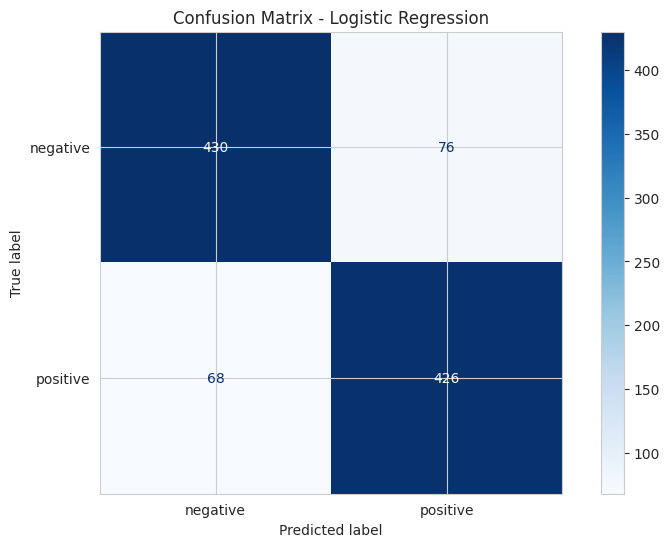

In [56]:
# Plot confusion matrix for Logistic Regression

cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=lr_model.classes_
)

disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

### 📊 Interpretation: Logistic Regression

**Overall performance:**
The Logistic Regression model performed well with an accuracy of **85.6%**. It correctly classified most movie reviews and achieved balanced precision, recall, and F1-scores for both positive and negative sentiments.

**Strengths:**
- High overall accuracy and F1-score (0.856).
- Performed consistently on both positive and negative reviews.
- Made a large number of correct predictions (856 out of 1,000).

**Weaknesses:**
- Some reviews were still misclassified, especially those with ambiguous or mixed sentiment.
- The model incorrectly predicted 76 negative reviews as positive and 68 positive reviews as negative.

**Confusion matrix insights:**
The confusion matrix shows that the model correctly classified **430 negative** reviews and **426 positive** reviews. It made **144 total errors**, with a similar number of false positives and false negatives, indicating that the model is balanced and does not favor one class over the other.

## Evaluate Model 2: Naive Bayes

In [57]:
# Calculate metrics for Naive Bayes

print("=" * 50)
print("NAIVE BAYES RESULTS")
print("=" * 50)

accuracy = accuracy_score(y_test, y_pred_nb)
precision = precision_score(y_test, y_pred_nb, average='weighted')
recall = recall_score(y_test, y_pred_nb, average='weighted')
f1 = f1_score(y_test, y_pred_nb, average='weighted')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_nb))

NAIVE BAYES RESULTS
Accuracy:  0.8430
Precision: 0.8430
Recall:    0.8430
F1-Score:  0.8430


Classification Report:
              precision    recall  f1-score   support

    negative       0.84      0.85      0.85       506
    positive       0.84      0.84      0.84       494

    accuracy                           0.84      1000
   macro avg       0.84      0.84      0.84      1000
weighted avg       0.84      0.84      0.84      1000



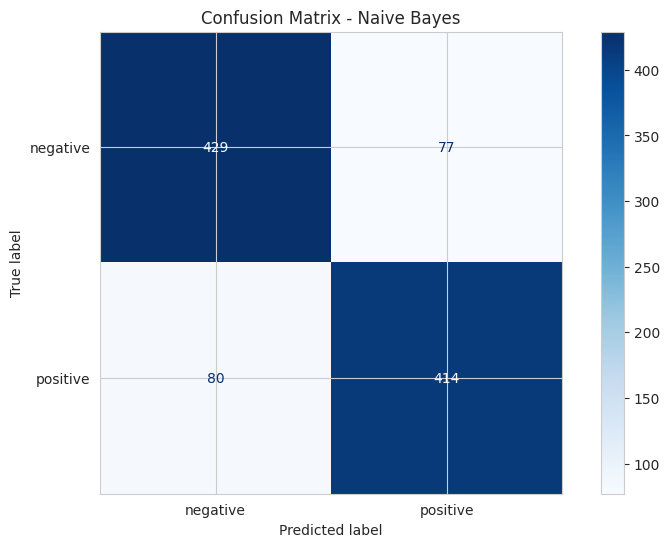

In [58]:
# Plot confusion matrix for Naive Bayes

cm = confusion_matrix(y_test, y_pred_nb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=nb_model.classes_
)

disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

### 📊 Interpretation: Naive Bayes

**Overall performance:**
The Naive Bayes model achieved an accuracy of **84.3%**. It performed well on the sentiment classification task but was slightly less accurate than the Logistic Regression model.

**Strengths:**
- Good overall accuracy and balanced precision, recall, and F1-score.
- Correctly classified most positive and negative reviews.
- Very fast to train and predict, making it efficient for text classification.

**Weaknesses:**
- Lower accuracy than Logistic Regression.
- Misclassified some reviews with mixed or unclear sentiment.
- Made more incorrect predictions overall than the Logistic Regression model.

**Confusion matrix insights:**
The confusion matrix shows that the model correctly classified **429 negative** reviews and **414 positive** reviews. It incorrectly classified **77 negative** reviews as positive and **80 positive** reviews as negative. The model performed similarly on both classes but made slightly more errors than Logistic Regression.

## Evaluate Model 3 (Optional)

In [59]:
# Calculate metrics for Random Forest

print("=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)

accuracy = accuracy_score(y_test, y_pred_rf)
precision = precision_score(y_test, y_pred_rf, average='weighted')
recall = recall_score(y_test, y_pred_rf, average='weighted')
f1 = f1_score(y_test, y_pred_rf, average='weighted')

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print("\n")

print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

RANDOM FOREST RESULTS
Accuracy:  0.8120
Precision: 0.8120
Recall:    0.8120
F1-Score:  0.8120


Classification Report:
              precision    recall  f1-score   support

    negative       0.82      0.81      0.81       506
    positive       0.81      0.81      0.81       494

    accuracy                           0.81      1000
   macro avg       0.81      0.81      0.81      1000
weighted avg       0.81      0.81      0.81      1000



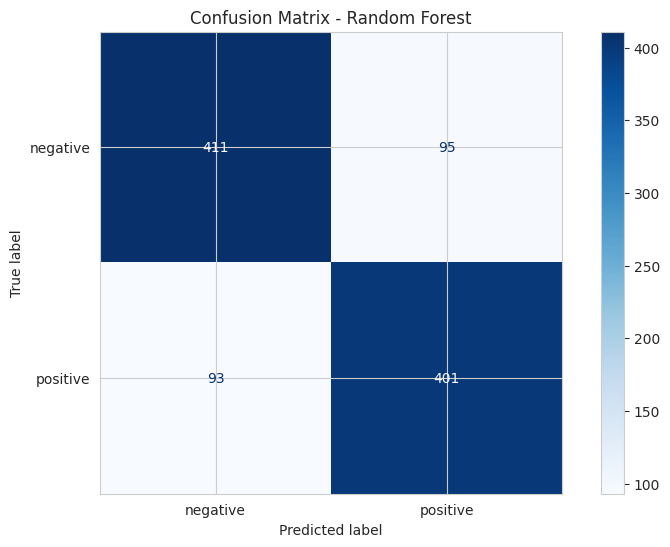

In [60]:
# Plot confusion matrix for Random Forest

cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_model.classes_
)

disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Random Forest')
plt.show()

## Model Comparison

In [61]:
# Create a comparison table of all models

results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Naive Bayes', 'Random Forest'],
    'Accuracy': [0.8560, 0.8430, 0.8120],
    'Precision': [0.8561, 0.8430, 0.8120],
    'Recall': [0.8560, 0.8430, 0.8120],
    'F1-Score': [0.8560, 0.8430, 0.8120]
})

display(results)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.856,0.8561,0.856,0.856
1,Naive Bayes,0.843,0.8430,0.843,0.843
2,Random Forest,0.812,0.8120,0.812,0.812


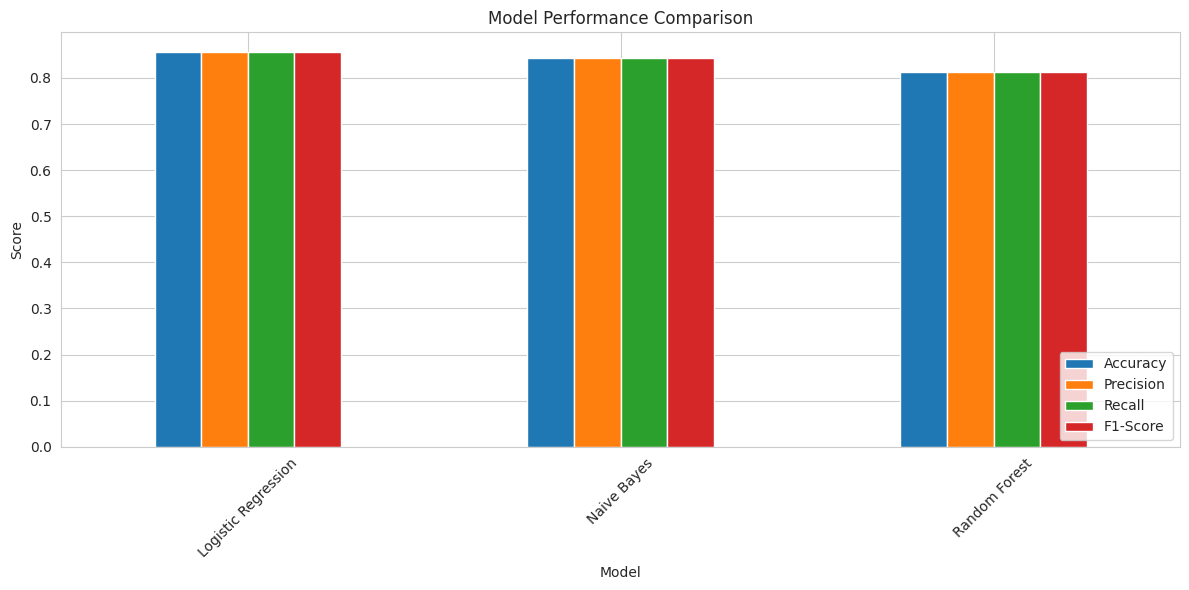

In [62]:
# Visualize model comparison

results.set_index('Model').plot(kind='bar', figsize=(12, 6))

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

### 📊 Model Comparison Analysis

**Which model performed best?:**
Logistic Regression performed the best overall. It achieved the highest accuracy (85.6%), precision (0.8561), recall (0.8560), and F1-score (0.8560). It consistently outperformed both Naive Bayes and Random Forest on the sentiment classification task.

**What metrics did you prioritize and why?:**
I prioritized the F1-score along with accuracy, precision, and recall. The F1-score is important because it balances precision and recall, giving a better measure of overall model performance. Since the dataset was fairly balanced between positive and negative reviews, accuracy was also a reliable metric for comparing the models.

**Trade-offs between models:**
Logistic Regression provided the best overall performance but required slightly more training time than Naive Bayes. Naive Bayes trained almost instantly and still achieved good performance, making it a good option when speed is important. Random Forest was the most complex model but produced the lowest accuracy on the TF-IDF features, making it the least effective choice for this dataset.

**Which model would you recommend for deployment?:**
I would recommend **Logistic Regression** for deployment because it achieved the highest performance across all evaluation metrics while maintaining balanced predictions for both positive and negative reviews. It provides the best combination of accuracy, reliability, and overall effectiveness for sentiment analysis.

## Error Analysis (Optional but Recommended)

In [63]:
# Analyze misclassified examples

misclassified_indices = np.where(y_pred_lr != y_test)[0]

print(f"Number of misclassified examples: {len(misclassified_indices)}")

# Display some misclassified examples
for idx in misclassified_indices[:5]:
    print(f"\nText: {X_test.iloc[idx]}")
    print(f"True label: {y_test.iloc[idx]}")
    print(f"Predicted label: {y_pred_lr[idx]}")
    print("-" * 80)

Number of misclassified examples: 144

Text: i watched this film for minutes and counted mullets thats a mullet every minutes seriously though this film is living proof that formula works if it aint broke it dont need fixin a streetwiseyetvulnerable heroine a hardened excop martial arts master with a heart of gold and a serial killer with issues pure magic
True label: negative
Predicted label: positive
--------------------------------------------------------------------------------

Text: i first saw this movie when i was a freshman in high school and the film has stuck with me through the years its not about the soundtrack or cinematography or even the dialogue and somewhat bad acting its about the educational purpose and the message behind that is the most important its not a sin to have a child when youre a teenager and still in high school and its not really a bad thing either but it is a problem tons of girls i knew are all having children now and i guess they never watched this g

### 📊 Error Analysis Insights

**Common types of errors:**
Many of the misclassified reviews contained mixed sentiment, where both positive and negative opinions appeared in the same review. Some reviews also included sarcasm or discussed both strengths and weaknesses before giving an overall opinion, making them more difficult for the model to classify correctly.

**Why might these errors occur?:**
The model uses TF-IDF features, which focus on individual words and phrases rather than understanding the overall context of a review. As a result, positive words like "great" or "magic" in a negative review, or negative words like "bad acting" in a positive review, can confuse the model. It also cannot fully understand sarcasm or the true meaning behind longer reviews.

**How could you improve the model?:**
The model could be improved by using more training data, tuning the model's hyperparameters, and experimenting with different text preprocessing techniques. More advanced language models, such as transformer-based models like BERT, could also better understand context and reduce errors on reviews with mixed sentiment or sarcasm.



### 💼 Conclusion & Business Insights

**Project Summary:**
In this project, I built and evaluated multiple machine learning models to classify IMDb movie reviews as positive or negative. After preprocessing the text and converting it into TF-IDF features, I trained Logistic Regression, Naive Bayes, and Random Forest models. Logistic Regression achieved the best overall performance with an accuracy of **85.6%**, outperforming the other models across all evaluation metrics.

**Business Recommendations:**
A sentiment analysis model like this could help businesses automatically analyze customer reviews and feedback. Companies could use the predictions to identify dissatisfied customers, monitor customer satisfaction, and discover common complaints or positive trends. This would allow businesses to respond more quickly to customer concerns and make data-driven decisions to improve their products or services.

**Limitations and Future Improvements:**
One limitation of this project is that the TF-IDF approach does not fully understand the context or meaning of words. Reviews containing sarcasm, mixed opinions, or complex language can be difficult for the model to classify correctly. Future improvements could include collecting more training data, tuning model hyperparameters, and using transformer-based language models such as BERT, which are better at understanding context and reducing classification errors.

**Reflection:**
This project helped me understand the complete machine learning workflow, from preprocessing text data to training, evaluating, and comparing multiple classification models. I learned how different algorithms perform on the same dataset and why evaluation metrics such as accuracy, precision, recall, and F1-score are important when selecting the best model. I also learned that analyzing model errors is an important step in improving future model performance.

### 📝 Executive Summary

This project developed a system that automatically identifies whether movie reviews are positive or negative. After comparing several machine learning models, Logistic Regression produced the best results, correctly classifying about **86%** of the reviews. A system like this could help businesses quickly understand customer feedback, identify common concerns, and improve customer satisfaction. Overall, the project showed that machine learning can be an effective tool for analyzing large amounts of customer opinions.

### 🎯 Key Findings

**Dataset insights:**
The IMDb dataset contained both positive and negative movie reviews, providing a balanced dataset for sentiment classification. After preprocessing and converting the text into TF-IDF features, the data was ready for training machine learning models.

**Model performance:**
All three models performed well, with Logistic Regression achieving the highest accuracy (**85.6%**), followed by Naive Bayes (**84.3%**) and Random Forest (**81.2%**). Logistic Regression also achieved the highest precision, recall, and F1-score, making it the most reliable model overall.

**Best model and why:**
Logistic Regression was the best-performing model because it consistently achieved the highest scores across all evaluation metrics while making balanced predictions for both positive and negative reviews. It provided the best combination of accuracy, reliability, and overall performance.

**Surprising discoveries:**
One surprising discovery was that the simpler Logistic Regression model outperformed the more complex Random Forest model. I also found that many classification errors occurred in reviews containing mixed opinions or sarcasm, showing that understanding context is still a challenge for traditional machine learning models.

### 💼 Business Recommendations

**Immediate applications:**
This model can be used to automatically analyze customer reviews, social media posts, or survey responses. Businesses can quickly identify positive and negative feedback without reading every comment manually, helping them respond to customer concerns more efficiently.

**Who should use this model?:**
This model would be useful for companies with large amounts of customer feedback, such as online retailers, streaming services, restaurants, hotels, and other businesses that want to monitor customer satisfaction and improve their products or services.

**How to interpret predictions:**
The model's predictions should be used as a helpful decision-making tool rather than a final judgment. Positive predictions generally indicate satisfied customers, while negative predictions may highlight reviews that require additional attention or follow-up.

**Warning signs to watch for:**
The model may make mistakes on reviews that contain sarcasm, mixed opinions, or complex language. Businesses should review important or uncertain predictions manually before making major decisions based on the results.

### ⚠️ Limitations

**Data limitations:**
The dataset only included IMDb movie reviews, so it may not represent other types of text such as product reviews, social media posts, or customer support messages. Although the dataset was balanced, it may not capture every writing style or opinion.

**Model limitations:**
The models relied on TF-IDF features, which focus on word frequency rather than understanding the full meaning of a sentence. Because of this, the models sometimes struggled with sarcasm, mixed opinions, and reviews containing both positive and negative language.

**Generalization concerns:**
The model was trained specifically on movie reviews, so its performance may decrease when applied to reviews from other industries or domains. Additional training data from different sources would likely improve its ability to generalize to new types of text.

**Resource constraints:**
To keep training efficient, the dataset was limited to a sample of 5,000 reviews and the TF-IDF features were capped at 5,000. Using a larger dataset or more advanced models could improve performance but would require more computing power and longer training times.

### 🚀 Future Improvements

**Data collection:**
With more time, I would collect a larger and more diverse dataset that includes reviews from different industries, social media platforms, and customer feedback sources. This would help the model learn a wider variety of writing styles and improve its ability to generalize.

**Feature engineering:**
I would experiment with additional text preprocessing techniques, such as lemmatization, sentiment lexicons, and different n-gram combinations. I would also tune the TF-IDF parameters and explore word embeddings to capture more meaningful relationships between words.

**Advanced models:**
I would compare the current models with more advanced approaches such as Support Vector Machines (SVM), XGBoost, and transformer-based models like BERT. These models are better at understanding context and may improve performance on reviews containing sarcasm or mixed sentiment.

**Deployment considerations:**
Before deploying the model, I would validate it on new real-world data, monitor its performance over time, and retrain it as new customer reviews become available. I would also build a simple web application or API so businesses could easily submit reviews and receive sentiment predictions in real time.

### 🎓 Lessons Learned

**Technical skills gained:**
Through this project, I learned how to preprocess text data, convert it into TF-IDF features, train multiple machine learning models, and evaluate their performance using accuracy, precision, recall, F1-score, and confusion matrices. I also gained experience comparing different models and interpreting their results.

**Challenges overcome:**
One of the biggest challenges was understanding why different models performed differently and interpreting the evaluation metrics. I also learned how to analyze model errors and recognize why some reviews were difficult to classify due to mixed sentiment or sarcasm.

**What would you do differently?:**
If I repeated this project, I would spend more time tuning the model hyperparameters and experimenting with additional text preprocessing techniques. I would also compare more advanced models to see whether they could improve performance on difficult reviews.

**Most valuable insight:**
The most valuable insight I gained is that building a machine learning model is more than achieving high accuracy. Understanding the data, evaluating model performance, analyzing errors, and recognizing the model's limitations are all essential steps in developing a reliable machine learning solution.

---

## 🎉 Congratulations!

You've completed the sentiment analysis project! Remember to:

- ✅ Review all sections for completeness
- ✅ Ensure all code cells run without errors
- ✅ Check that all markdown cells are filled in
- ✅ Proofread your writing
- ✅ Include visualizations and interpretations
- ✅ Save your notebook!

---

### 📚 Additional Resources

- [Scikit-learn Documentation](https://scikit-learn.org/)
- [TF-IDF Explained](https://en.wikipedia.org/wiki/Tf%E2%80%93idf)
- [Confusion Matrix Guide](https://en.wikipedia.org/wiki/Confusion_matrix)
- [Text Preprocessing Best Practices](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction)

---

*Good luck with your project! 🚀*